In [1]:
# --- Core libraries ---
import os
import json
import re
from collections import Counter

# --- Data handling ---
import pandas as pd
from datasets import load_dataset

# --- Optional visualization ---
import matplotlib.pyplot as plt
import seaborn as sns
# Text processing
import emoji
from bs4 import BeautifulSoup

# Transformers
from transformers import AutoTokenizer
# --- Display settings ---
pd.set_option('display.max_colwidth', 500)
sns.set(style="whitegrid")

c:\Users\ASUS\Downloads\Fraud-Detection\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
data_dir = "../data"
domains = [
    "phishing",
    "fake_news",
    "political_statements",
    "product_reviews",
    "job_scams",
    "sms",
    "twitter_rumours"
]
splits = ["train.jsonl", "validation.jsonl", "test.jsonl"]

# Step 1: Load 

In [3]:
def load_jsonl(filepath):
    """Load a .jsonl file into a pandas DataFrame"""
    data = []
    with open(filepath, encoding="utf-8") as f:
        for line in f:
            data.append(json.loads(line))
    return pd.DataFrame(data)


In [4]:
def load_domain_data(domain, data_dir="../data"):
    """
    Load train, validation, and test JSONL files for a given domain.
    Returns a dict of DataFrames and a combined DataFrame.
    """
    domain_path = os.path.join(data_dir, domain)
    splits = ["train.jsonl", "validation.jsonl", "test.jsonl"]
    dfs = {}
    
    for split in splits:
        path = os.path.join(domain_path, split)
        if os.path.exists(path):
            dfs[split.split(".")[0]] = load_jsonl(path)
        else:
            print(f"⚠️ {split} not found for {domain}")
            dfs[split.split(".")[0]] = pd.DataFrame()
    
    dfs["all"] = pd.concat([df for df in dfs.values() if not df.empty], ignore_index=True)
    return dfs


### **Step 1: Text Cleaning & Normalization**

In [5]:
def clean_text_basic(text, remove_html=True):
    """Clean a single text sample."""
    if not isinstance(text, str):
        text = str(text)
    
    if remove_html:
        text = BeautifulSoup(text, "html.parser").get_text()
    
    text = re.sub(r"http\S+|www\S+|https\S+", "<URL>", text)
    text = re.sub(r"\S+@\S+", "<EMAIL>", text)
    text = emoji.replace_emoji(text, replace="<EMOJI>")
    text = re.sub(r"[^a-zA-Z0-9\s.,!?'<>()]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    
    return text

def apply_cleaning(df, text_col="text"):
    """Apply text cleaning to a DataFrame"""
    df["clean_text"] = df[text_col].apply(clean_text_basic)
    return df


In [6]:
domain = "job_scams"
dfs = load_domain_data(domain, data_dir)
all_df = dfs["all"]

all_df = apply_cleaning(all_df)

# Show examples
for i in range(2):
    print(f"--- Sample {i+1} ---")
    print("Original:", all_df['text'].iloc[i])
    print("Cleaned:", all_df['clean_text'].iloc[i])
    print("-" * 60)


--- Sample 1 ---
Original: The Role: To lead and develop our cutting edge mobile casino web applications, based on front line technologies and architecture. Integration and implementation of third party providers. Deliver high quality code and high performance product by requirements. Working closely with other staff, such as Project Managers, Graphic Artists, Designers, Developers, Systems Analysts, and Sales and Marketing professionals
Cleaned: The Role To lead and develop our cutting edge mobile casino web applications, based on front line technologies and architecture. Integration and implementation of third party providers. Deliver high quality code and high performance product by requirements. Working closely with other staff, such as Project Managers, Graphic Artists, Designers, Developers, Systems Analysts, and Sales and Marketing professionals
------------------------------------------------------------
--- Sample 2 ---
Original: We are looking for a creative and proficient in

In [7]:
from transformers import AutoTokenizer, AutoModelForMaskedLM
import torch

# Load DeBERTa-v3-base with slow tokenizer to avoid Windows issues
tokenizer = AutoTokenizer.from_pretrained("microsoft/deberta-v3-base", use_fast=False)
model = AutoModelForMaskedLM.from_pretrained("microsoft/deberta-v3-base")

def tokenize_texts(texts, max_length=512, stride=128, use_stride=False):
    """
    Tokenize a single string or list of strings.
    Supports overlapping chunks for long texts if use_stride=True.
    Returns a dict with input_ids, attention_mask, and optional sample_mapping.
    """
    if not isinstance(texts, list):
        texts = [texts]

    encoded = tokenizer(
        texts,
        truncation=True,
        padding="max_length",
        max_length=max_length,
        stride=stride if use_stride else 0,
        return_overflowing_tokens=use_stride,
        return_tensors="pt"
    )

    # Handle long text chunks
    if use_stride and "overflow_to_sample_mapping" in encoded:
        encoded['sample_mapping'] = encoded.pop("overflow_to_sample_mapping")
    else:
        # Ensure sample_mapping always exists for consistency
        encoded['sample_mapping'] = torch.arange(len(texts))

    return encoded

def tokenize_dataset(df, text_column="clean_text", max_length=512, stride=128, use_stride=False):
    """
    Tokenize a DataFrame column containing text.
    Returns tokenized outputs suitable for PyTorch DataLoader.
    """
    texts = df[text_column].tolist()
    return tokenize_texts(texts, max_length=max_length, stride=stride, use_stride=use_stride)

def flatten_tokenized(encoded):
    """
    Flatten tokenized outputs into individual examples for training.
    Handles overflowing chunks correctly.
    """
    input_ids = encoded['input_ids']
    attention_mask = encoded['attention_mask']
    sample_mapping = encoded['sample_mapping']

    # Flatten tensors to one dimension per chunk
    return {
        'input_ids': input_ids.view(-1, input_ids.size(-1)),
        'attention_mask': attention_mask.view(-1, attention_mask.size(-1)),
        'sample_mapping': sample_mapping.view(-1)
    }


Some weights of DebertaV2ForMaskedLM were not initialized from the model checkpoint at microsoft/deberta-v3-base and are newly initialized: ['cls.predictions.bias', 'cls.predictions.decoder.bias', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.transform.dense.bias', 'cls.predictions.transform.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [8]:
import pandas as pd

df = pd.DataFrame({
    "clean_text": [
        "This is a short sentence.",
        "This is a very long text " * 50  # simulate long text
    ]
})

tokens = tokenize_dataset(df, max_length=128, stride=32, use_stride=True)
tokens_flat = flatten_tokenized(tokens)

print(tokens_flat['input_ids'].shape)       # (total_chunks, 128)
print(tokens_flat['attention_mask'].shape)  # (total_chunks, 128)
print(tokens_flat['sample_mapping'])        # maps each chunk to original row


torch.Size([2, 128])
torch.Size([2, 128])
tensor([0, 1])


In [9]:
sample_texts = all_df['clean_text'].sample(3, random_state=42).tolist()
encodings = tokenize_texts(sample_texts, use_stride=False)

for i, text in enumerate(sample_texts):
    print(f"--- Sample {i+1} ---")
    print("Text snippet:", text[:200], "...")
    print("Input IDs length:", len(encodings['input_ids'][i]))
    print("Attention mask sum:", encodings['attention_mask'][i].sum().item())
    print("-" * 50)


--- Sample 1 ---
Text snippet: Position Principal Product Applications Engineer MACsec FCoE Job Location United States California Irvine Us work status required H1B EAD Green Card US Citizens Detailed Description Job Requirements T ...
Input IDs length: 512
Attention mask sum: 348
--------------------------------------------------
--- Sample 2 ---
Text snippet: Title VP, Healthcare Management Location Las Vegas, Nevada (Relocation Package Available) Client Organization Fortune 1000 Compensation 150,000 200,000 Base Salary 40 Bonus, Benefits Reports to SVP, C ...
Input IDs length: 512
Attention mask sum: 110
--------------------------------------------------
--- Sample 3 ---
Text snippet: The Customer Service Associate will be based in Indianapolis, IN. The right candidate will be an integral part of our talented team, supporting our continued growth. Goal Our goal is to have 100 parti ...
Input IDs length: 512
Attention mask sum: 312
--------------------------------------------------


In [10]:
# ============================================================
# 🚨 Fraud cue feature engineering (semantic expansion)
# ============================================================
from sentence_transformers import SentenceTransformer, util
import re

# 1️⃣ Load a lightweight semantic model
semantic_model = SentenceTransformer("all-MiniLM-L6-v2")

# 2️⃣ Base suspicious words
base_keywords = [
    "urgent", "click", "verify", "winner", "lottery", "account", 
    "free", "login", "password", "update", "limited", "congratulations",
    "refund", "credit card", "bank", "ssn", "payment", "offer", "apply"
]

# 3️⃣ Extra general vocabulary to search for semantically related terms
candidate_vocab = [
    "register", "secure", "deal", "bonus", "cashback", "promotion",
    "credentials", "details", "info", "security", "confirm", "alert",
    "restricted", "deadline", "access", "pin", "gift", "coupon", "transaction"
]

def expand_keywords(base_words, vocab, threshold=0.55):
    """Find semantically similar words in the vocabulary to expand fraud cues."""
    base_emb = semantic_model.encode(base_words, convert_to_tensor=True)
    vocab_emb = semantic_model.encode(vocab, convert_to_tensor=True)

    expanded = set(base_words)
    for i, bw in enumerate(base_words):
        sims = util.cos_sim(base_emb[i], vocab_emb)[0]
        for j, score in enumerate(sims):
            if score > threshold:
                expanded.add(vocab[j])
    return list(expanded)

# Generate your expanded fraud keyword list once
expanded_keywords = expand_keywords(base_keywords, candidate_vocab)
print(f"🔍 Expanded fraud keyword list ({len(expanded_keywords)}): {expanded_keywords}")

# 4️⃣ Feature extraction function
def extract_fraud_features(df, text_col="clean_text", keyword_list=None):
    """Add fraud cue features: URL, email, suspicious keyword counts."""
    if keyword_list is None:
        keyword_list = expanded_keywords

    pattern = re.compile(r"\b(" + "|".join(re.escape(w) for w in keyword_list) + r")\b", re.IGNORECASE)

    df["url_count"] = df[text_col].str.count("<URL>")
    df["email_count"] = df[text_col].str.count("<EMAIL>")
    df["suspicious_keyword_count"] = df[text_col].apply(lambda x: len(pattern.findall(x)))
    df["has_suspicious_term"] = (df["suspicious_keyword_count"] > 0).astype(int)

    return df


🔍 Expanded fraud keyword list (24): ['free', 'apply', 'bank', 'urgent', 'credit card', 'confirm', 'offer', 'password', 'restricted', 'login', 'congratulations', 'account', 'credentials', 'lottery', 'ssn', 'transaction', 'limited', 'update', 'verify', 'winner', 'deal', 'refund', 'payment', 'click']


In [11]:
from bs4 import MarkupResemblesLocatorWarning
import warnings

# Ignore BeautifulSoup "looks like a filename" warning
warnings.filterwarnings("ignore", category=MarkupResemblesLocatorWarning)

# Dictionary to store cleaned + tokenized DataFrames per domain
processed_domains = {}

for domain in domains:
    print(f"Processing domain: {domain} ...")
    
    dfs = load_domain_data(domain, data_dir)
    all_df = dfs["all"]

    if all_df.empty:
        print(f"⚠️ No data found for {domain}, skipping...")
        continue

    # Step 1: Clean text
    all_df = apply_cleaning(all_df)

    # ✅ Step 2: Add fraud cue features (NEW)
    all_df = extract_fraud_features(all_df)

    # Step 3: Tokenize text
    encodings = tokenize_dataset(all_df, text_column="clean_text")

    # Step 4: Build DataFrame
    tokenized_df = pd.DataFrame({
        "text": all_df["clean_text"].tolist(),
        "input_ids": list(encodings["input_ids"].numpy()),
        "attention_mask": list(encodings["attention_mask"].numpy()),
        "url_count": all_df["url_count"],
        "email_count": all_df["email_count"],
        "suspicious_keyword_count": all_df["suspicious_keyword_count"],
        "has_suspicious_term": all_df["has_suspicious_term"]
    })

    if "label" in all_df.columns:
        tokenized_df["label"] = all_df["label"]

    processed_domains[domain] = tokenized_df

print("✅ All domains processed. Each domain has its own cleaned + tokenized DataFrame.")


Processing domain: phishing ...
Processing domain: fake_news ...
Processing domain: political_statements ...
Processing domain: product_reviews ...
Processing domain: job_scams ...
Processing domain: sms ...
Processing domain: twitter_rumours ...
✅ All domains processed. Each domain has its own cleaned + tokenized DataFrame.


In [12]:
# Access a specific domain
job_scams_df = processed_domains["job_scams"]
print(job_scams_df.head())

# Save for future use
for domain, df in processed_domains.items():
    df.to_pickle(f"../data/processed_{domain}.pkl")  # keeps input_ids/attention_mask as tensors


                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                  text  \
0                                                                                        The Role To lead and develop our cutting edge mobile casino web applications, based on front line technologies and architecture. Integration and implementation of third party providers. Deliver high quality code and high performance product by requirements. Working closely with other staff, such as Project Managers, Graphic Artists, Designers, Developers, Systems Analysts, and Sales and Marketing profe

In [13]:
all_encodings = tokenize_dataset(all_df)

print("Number of sequences:", len(all_encodings['input_ids']))
print("Example input IDs (first text):", all_encodings['input_ids'][0][:20])
print("Example attention mask (first text):", all_encodings['attention_mask'][0][:20])


Number of sequences: 5789
Example input IDs (first text): tensor([  1, 273, 418, 280, 297, 391, 361, 291, 269, 446, 264, 513, 260, 420,
        642, 261, 278, 702, 280, 297])
Example attention mask (first text): tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])


### Label Preparation


In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import torch
from sklearn.utils.class_weight import compute_class_weight

# ============================================================
# 🎯 1. Verify Label Distribution
# ============================================================
def check_label_distribution(df, label_col="label", plot=True):
    """
    Check and visualize label distribution.
    Returns a Counter or Series for the label counts.
    """
    label_counts = df[label_col].value_counts()
    print("Label distribution:\n", label_counts)

    if plot:
        sns.barplot(x=label_counts.index, y=label_counts.values, palette="viridis")
        plt.title(f"Label Distribution in {label_col} (0 = Real, 1 = Deceptive)")
        plt.xlabel("Label")
        plt.ylabel("Count")
        plt.show()

    return label_counts



In [15]:
# ============================================================
# ⚖️ 2. Compute Class Weights (for imbalanced datasets)
# ============================================================
def compute_class_weights(df, label_col="label"):
    """
    Compute balanced class weights for model training.
    Returns a dictionary mapping each class to its weight.
    """
    classes = np.unique(df[label_col])
    weights = compute_class_weight(
        class_weight="balanced", 
        classes=classes, 
        y=df[label_col]
    )
    class_weights = dict(zip(classes, weights))
    print("Computed class weights:", class_weights)
    return class_weights


In [16]:
# ============================================================
# 📦 3. Convert Labels to Tensor
# ============================================================
def prepare_label_tensor(df, label_col="label"):
    """
    Convert label column to a PyTorch tensor.
    Ensures correct dtype for model training.
    """
    labels_tensor = torch.tensor(df[label_col].values, dtype=torch.long)
    print("✅ Labels tensor shape:", labels_tensor.shape)
    print("Example labels:", labels_tensor[:10])
    return labels_tensor

--- phishing ---
Label distribution:
 label
0    9198
1    6074
Name: count, dtype: int64


C:\Users\ASUS\AppData\Local\Temp\ipykernel_18764\2252940944.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=label_counts.index, y=label_counts.values, palette="viridis")


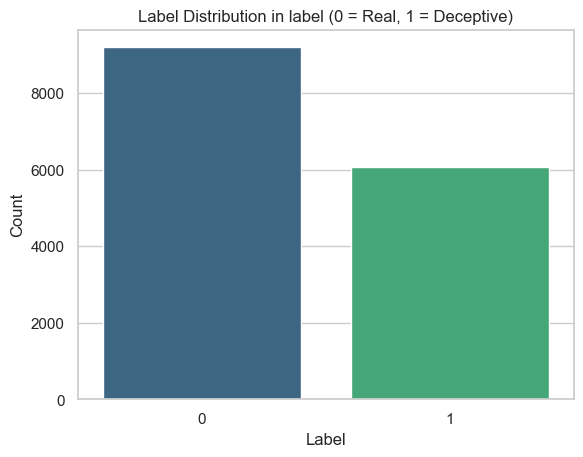

--- fake_news ---
Label distribution:
 label
0    11624
1     8832
Name: count, dtype: int64


C:\Users\ASUS\AppData\Local\Temp\ipykernel_18764\2252940944.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=label_counts.index, y=label_counts.values, palette="viridis")


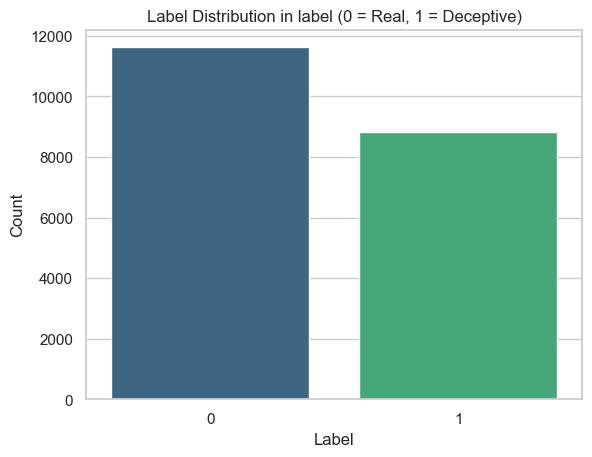

C:\Users\ASUS\AppData\Local\Temp\ipykernel_18764\2252940944.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=label_counts.index, y=label_counts.values, palette="viridis")


--- political_statements ---
Label distribution:
 label
1    8042
0    4455
Name: count, dtype: int64


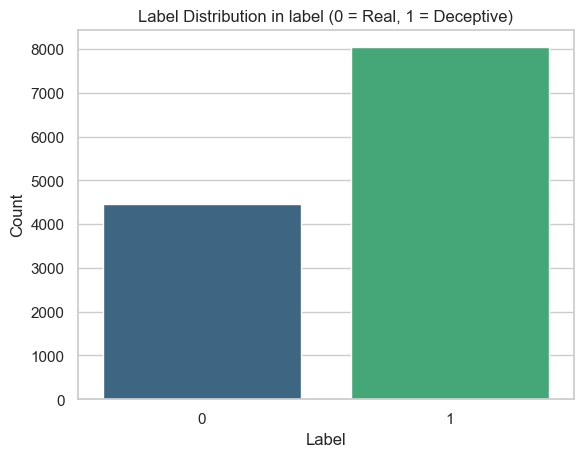

--- product_reviews ---
Label distribution:
 label
1    10492
0    10479
Name: count, dtype: int64


C:\Users\ASUS\AppData\Local\Temp\ipykernel_18764\2252940944.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=label_counts.index, y=label_counts.values, palette="viridis")


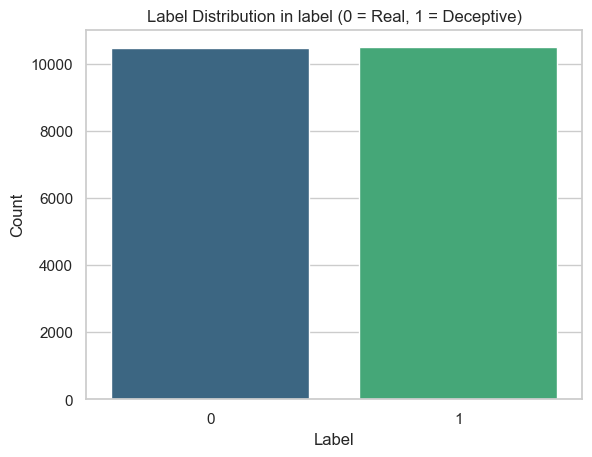

--- job_scams ---
Label distribution:
 label
0    13696
1      599
Name: count, dtype: int64


C:\Users\ASUS\AppData\Local\Temp\ipykernel_18764\2252940944.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=label_counts.index, y=label_counts.values, palette="viridis")


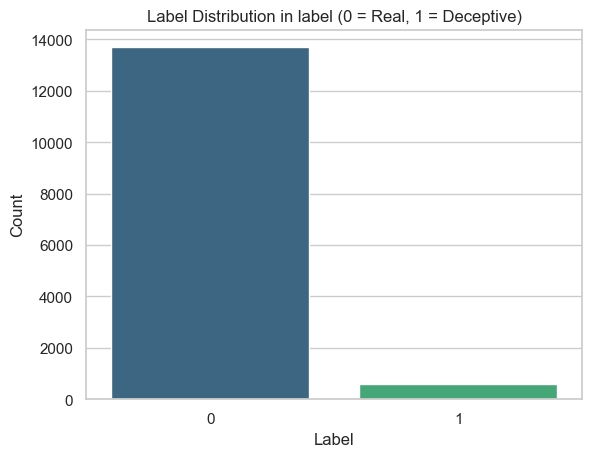

--- sms ---
Label distribution:
 label
0    5300
1    1274
Name: count, dtype: int64


C:\Users\ASUS\AppData\Local\Temp\ipykernel_18764\2252940944.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=label_counts.index, y=label_counts.values, palette="viridis")


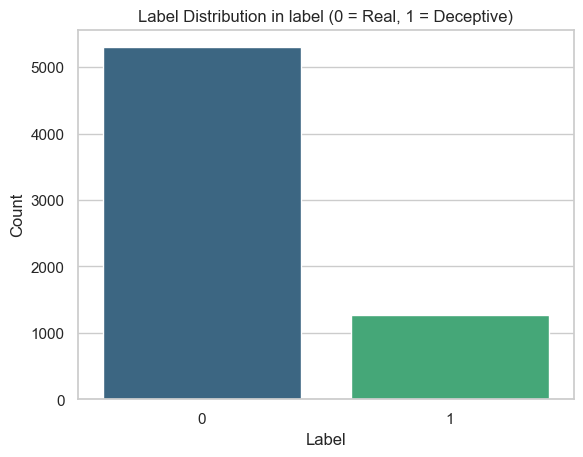

--- twitter_rumours ---
Label distribution:
 label
0    3820
1    1969
Name: count, dtype: int64


C:\Users\ASUS\AppData\Local\Temp\ipykernel_18764\2252940944.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=label_counts.index, y=label_counts.values, palette="viridis")


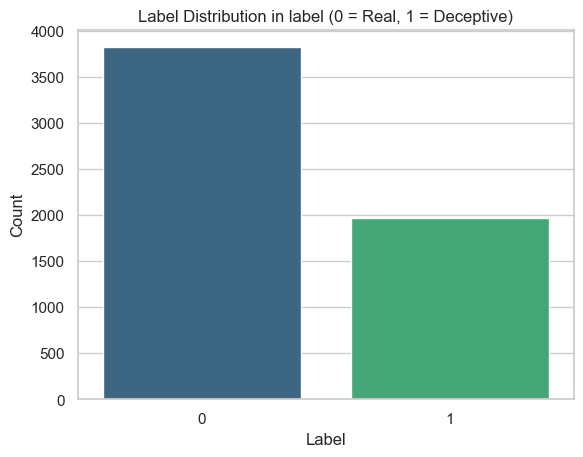

In [17]:
for domain, df in processed_domains.items():
    print(f"--- {domain} ---")
    if "label" in df.columns:
        check_label_distribution(df, label_col="label")
    else:
        print("⚠️ No labels available for this domain.\n")


In [18]:
for domain, df in processed_domains.items():
    if "label" in df.columns:
        print(f"--- {domain} ---")
        # Compute class weights
        class_weights = compute_class_weights(df, label_col="label")
        
        # Pretty print
        print("Class weights (0 = Real, 1 = Deceptive):")
        for cls, weight in class_weights.items():
            print(f"  Class {cls}: {weight:.3f}")
        print("-" * 50)


--- phishing ---
Computed class weights: {np.int64(0): np.float64(0.8301804740160904), np.int64(1): np.float64(1.2571616727033257)}
Class weights (0 = Real, 1 = Deceptive):
  Class 0: 0.830
  Class 1: 1.257
--------------------------------------------------
--- fake_news ---
Computed class weights: {np.int64(0): np.float64(0.8799036476256022), np.int64(1): np.float64(1.1580615942028984)}
Class weights (0 = Real, 1 = Deceptive):
  Class 0: 0.880
  Class 1: 1.158
--------------------------------------------------
--- political_statements ---
Computed class weights: {np.int64(0): np.float64(1.402581369248036), np.int64(1): np.float64(0.7769833374782392)}
Class weights (0 = Real, 1 = Deceptive):
  Class 0: 1.403
  Class 1: 0.777
--------------------------------------------------
--- product_reviews ---
Computed class weights: {np.int64(0): np.float64(1.0006202881954385), np.int64(1): np.float64(0.9993804803659931)}
Class weights (0 = Real, 1 = Deceptive):
  Class 0: 1.001
  Class 1: 0.999


In [19]:
def prepare_domains_for_training(processed_domains):
    """
    Takes a dictionary of cleaned + tokenized DataFrames per domain.
    For each domain:
    1. Plots label distribution
    2. Computes class weights
    3. Prepares PyTorch label tensors
    Returns:
        - domain_class_weights: dict of class weights per domain
        - domain_labels_tensor: dict of PyTorch tensors per domain
    """
    import matplotlib.pyplot as plt
    import seaborn as sns
    import numpy as np
    from sklearn.utils.class_weight import compute_class_weight
    import torch

    domain_class_weights = {}
    domain_labels_tensor = {}

    for domain, df in processed_domains.items():
        print(f"=== {domain} ===")

        if "label" not in df.columns:
            print("⚠️ No labels available for this domain.\n")
            continue

        # 1️⃣ Label distribution
        label_counts = df["label"].value_counts()
        print("Label distribution:\n", label_counts)

        sns.barplot(x=label_counts.index, y=label_counts.values, palette="viridis", dodge=False)
        plt.title(f"Label Distribution in {domain} (0 = Real, 1 = Deceptive)")
        plt.xlabel("Label")
        plt.ylabel("Count")
        plt.show()

        # 2️⃣ Class weights
        classes = np.unique(df["label"])
        weights = compute_class_weight(class_weight="balanced", classes=classes, y=df["label"])
        class_weights = dict(zip(classes, weights))
        domain_class_weights[domain] = class_weights

        print("Class weights (0 = Real, 1 = Deceptive):")
        for cls, weight in class_weights.items():
            print(f"  Class {cls}: {weight:.3f}")
        print("-" * 50)

        # 3️⃣ Prepare PyTorch label tensor
        labels_tensor = torch.tensor(df["label"].values, dtype=torch.long)
        domain_labels_tensor[domain] = labels_tensor
        print(f"Labels tensor shape: {labels_tensor.shape}\n")

    return domain_class_weights, domain_labels_tensor


=== phishing ===
Label distribution:
 label
0    9198
1    6074
Name: count, dtype: int64


C:\Users\ASUS\AppData\Local\Temp\ipykernel_18764\4020309488.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=label_counts.index, y=label_counts.values, palette="viridis", dodge=False)


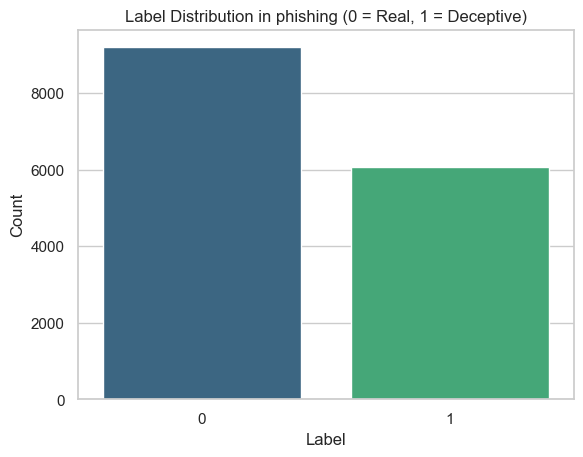

Class weights (0 = Real, 1 = Deceptive):
  Class 0: 0.830
  Class 1: 1.257
--------------------------------------------------
Labels tensor shape: torch.Size([15272])

=== fake_news ===
Label distribution:
 label
0    11624
1     8832
Name: count, dtype: int64


C:\Users\ASUS\AppData\Local\Temp\ipykernel_18764\4020309488.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=label_counts.index, y=label_counts.values, palette="viridis", dodge=False)


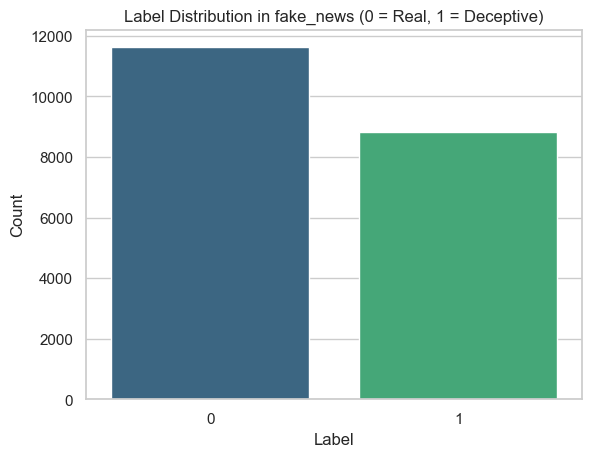

Class weights (0 = Real, 1 = Deceptive):
  Class 0: 0.880
  Class 1: 1.158
--------------------------------------------------
Labels tensor shape: torch.Size([20456])

=== political_statements ===
Label distribution:
 label
1    8042
0    4455
Name: count, dtype: int64


C:\Users\ASUS\AppData\Local\Temp\ipykernel_18764\4020309488.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=label_counts.index, y=label_counts.values, palette="viridis", dodge=False)


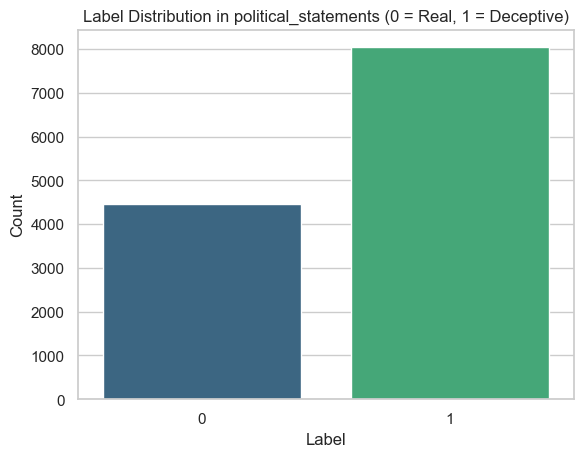

C:\Users\ASUS\AppData\Local\Temp\ipykernel_18764\4020309488.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=label_counts.index, y=label_counts.values, palette="viridis", dodge=False)


Class weights (0 = Real, 1 = Deceptive):
  Class 0: 1.403
  Class 1: 0.777
--------------------------------------------------
Labels tensor shape: torch.Size([12497])

=== product_reviews ===
Label distribution:
 label
1    10492
0    10479
Name: count, dtype: int64


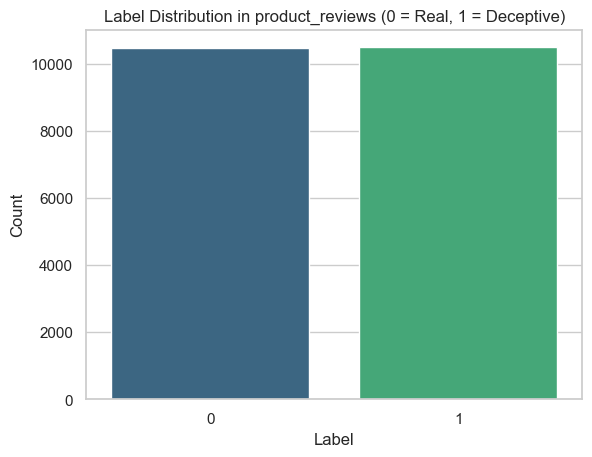

Class weights (0 = Real, 1 = Deceptive):
  Class 0: 1.001
  Class 1: 0.999
--------------------------------------------------
Labels tensor shape: torch.Size([20971])

=== job_scams ===
Label distribution:
 label
0    13696
1      599
Name: count, dtype: int64


C:\Users\ASUS\AppData\Local\Temp\ipykernel_18764\4020309488.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=label_counts.index, y=label_counts.values, palette="viridis", dodge=False)


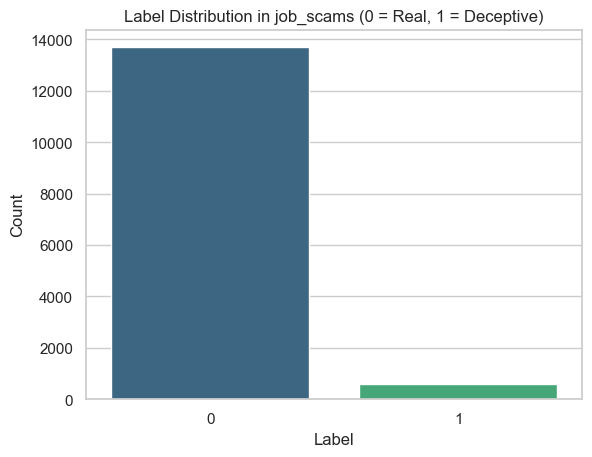

Class weights (0 = Real, 1 = Deceptive):
  Class 0: 0.522
  Class 1: 11.932
--------------------------------------------------
Labels tensor shape: torch.Size([14295])

=== sms ===
Label distribution:
 label
0    5300
1    1274
Name: count, dtype: int64


C:\Users\ASUS\AppData\Local\Temp\ipykernel_18764\4020309488.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=label_counts.index, y=label_counts.values, palette="viridis", dodge=False)


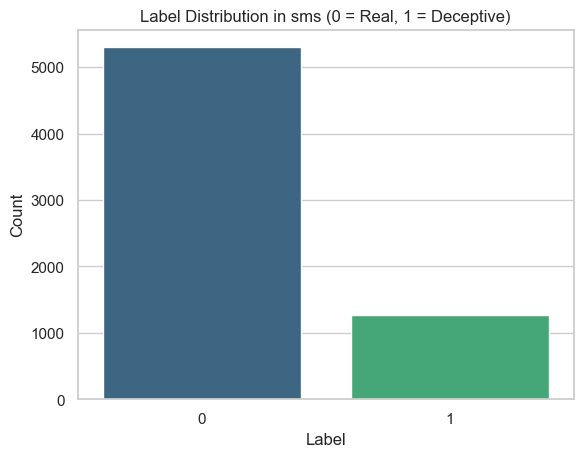

Class weights (0 = Real, 1 = Deceptive):
  Class 0: 0.620
  Class 1: 2.580
--------------------------------------------------
Labels tensor shape: torch.Size([6574])

=== twitter_rumours ===
Label distribution:
 label
0    3820
1    1969
Name: count, dtype: int64


C:\Users\ASUS\AppData\Local\Temp\ipykernel_18764\4020309488.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=label_counts.index, y=label_counts.values, palette="viridis", dodge=False)


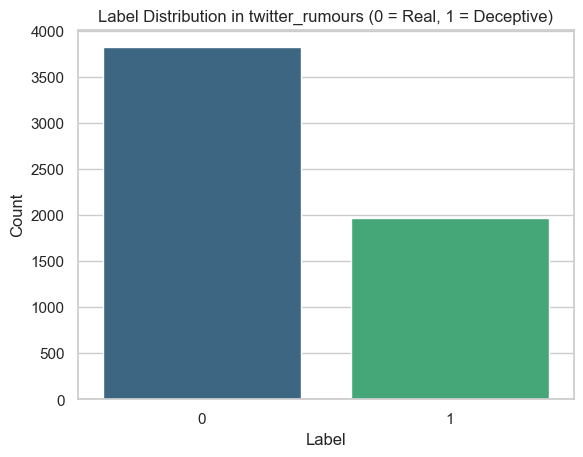

Class weights (0 = Real, 1 = Deceptive):
  Class 0: 0.758
  Class 1: 1.470
--------------------------------------------------
Labels tensor shape: torch.Size([5789])



In [20]:
domain_class_weights, domain_labels_tensor = prepare_domains_for_training(processed_domains)

In [21]:
import torch
from torch.utils.data import Dataset

class FraudDatasetWithFeatures(Dataset):
    """
    Wraps tokenized text, labels, and optional numeric features into a PyTorch Dataset.
    """
    def __init__(self, df, feature_cols=None):
        self.input_ids = [torch.tensor(ids, dtype=torch.long) for ids in df["input_ids"]]
        self.attention_mask = [torch.tensor(mask, dtype=torch.long) for mask in df["attention_mask"]]
        self.labels = [torch.tensor(lbl, dtype=torch.long) for lbl in df["label"]]

        # Optional numeric features (fraud cues)
        if feature_cols is not None:
            self.features = [torch.tensor(row, dtype=torch.float) for row in df[feature_cols].values]
        else:
            self.features = None

    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, idx):
        item = {
            "input_ids": self.input_ids[idx],
            "attention_mask": self.attention_mask[idx],
            "labels": self.labels[idx]
        }
        if self.features is not None:
            item["features"] = self.features[idx]
        return item


In [22]:
fraud_feature_cols = [
    "url_count",
    "email_count",
    "suspicious_keyword_count",
    "has_suspicious_term"
]


In [23]:
domain_datasets = {}

for domain, df in processed_domains.items():
    if "label" in df.columns:
        domain_datasets[domain] = FraudDatasetWithFeatures(df, feature_cols=fraud_feature_cols)
        print(f"✅ Dataset ready for domain: {domain} | {len(df)} samples")
    else:
        print(f"⚠️ No labels in {domain}, skipped.")


✅ Dataset ready for domain: phishing | 15272 samples
✅ Dataset ready for domain: fake_news | 20456 samples
✅ Dataset ready for domain: political_statements | 12497 samples
✅ Dataset ready for domain: product_reviews | 20971 samples
✅ Dataset ready for domain: job_scams | 14295 samples
✅ Dataset ready for domain: sms | 6574 samples
✅ Dataset ready for domain: twitter_rumours | 5789 samples


In [24]:
# Create a dict of loss functions per domain
domain_loss_fns = {}

for domain, weights_dict in domain_class_weights.items():
    weights_tensor = torch.tensor(list(weights_dict.values()), dtype=torch.float)
    domain_loss_fns[domain] = torch.nn.CrossEntropyLoss(weight=weights_tensor)
    print(f"✅ Weighted CrossEntropyLoss ready for domain: {domain}")


✅ Weighted CrossEntropyLoss ready for domain: phishing
✅ Weighted CrossEntropyLoss ready for domain: fake_news
✅ Weighted CrossEntropyLoss ready for domain: political_statements
✅ Weighted CrossEntropyLoss ready for domain: product_reviews
✅ Weighted CrossEntropyLoss ready for domain: job_scams
✅ Weighted CrossEntropyLoss ready for domain: sms
✅ Weighted CrossEntropyLoss ready for domain: twitter_rumours


In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def summarize_domains(processed_domains, max_token_preview=20):
    """
    Prints and visualizes key stats for each domain:
    - Number of samples
    - Average text length (tokens)
    - Label distribution
    - Example tokens / attention masks
    """
    for domain, df in processed_domains.items():
        print(f"\n=== Domain: {domain} ===")
        n_samples = len(df)
        print(f"Number of samples: {n_samples}")

        # Average text length in tokens
        avg_len = np.mean([len(ids) for ids in df["input_ids"]])
        print(f"Average tokenized length: {avg_len:.1f}")

        # Label distribution
        if "label" in df.columns:
            counts = df["label"].value_counts()
            print(f"Label distribution:\n{counts.to_dict()}")

            # Optional plot
            sns.barplot(x=counts.index, y=counts.values, palette="viridis", dodge=False)
            plt.title(f"Label Distribution in {domain}")
            plt.xlabel("Label")
            plt.ylabel("Count")
            plt.show()

        # Show a few token examples
        print("\nExample token ids and attention masks:")
        for i in range(min(3, n_samples)):
            print(f"Sample {i+1}:")
            print("input_ids:", df["input_ids"].iloc[i][:max_token_preview])
            print("attention_mask:", df["attention_mask"].iloc[i][:max_token_preview])
            print("label:", df["label"].iloc[i] if "label" in df.columns else "N/A")
            print("-"*40)



=== Domain: phishing ===
Number of samples: 15272
Average tokenized length: 512.0
Label distribution:
{0: 9198, 1: 6074}


C:\Users\ASUS\AppData\Local\Temp\ipykernel_18764\3923799651.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette="viridis", dodge=False)


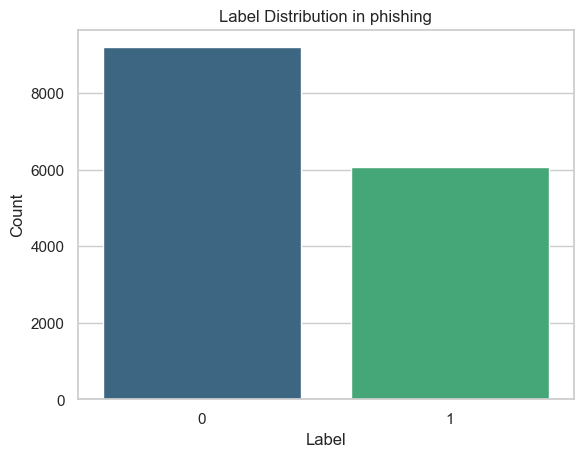


Example token ids and attention masks:
Sample 1:
input_ids: [    1 96748   261   662 17482  5588 11926 82270 33588   261 12778  1410
 11025 43840  9836   795   266   667  3316   300]
attention_mask: [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
label: 0
----------------------------------------
Sample 2:
input_ids: [    1  3638   673 10068 65840 31847  1829  8859 69653   578  5211  5621
  3725     2     0     0     0     0     0     0]
attention_mask: [1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0]
label: 0
----------------------------------------
Sample 3:
input_ids: [    1   279  3448 15581  1057   262  9539   961 58348   457  1130   749
   263 72808   430   270  8077 31027   270   262]
attention_mask: [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
label: 0
----------------------------------------

=== Domain: fake_news ===
Number of samples: 20456
Average tokenized length: 512.0
Label distribution:
{0: 11624, 1: 8832}


C:\Users\ASUS\AppData\Local\Temp\ipykernel_18764\3923799651.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette="viridis", dodge=False)


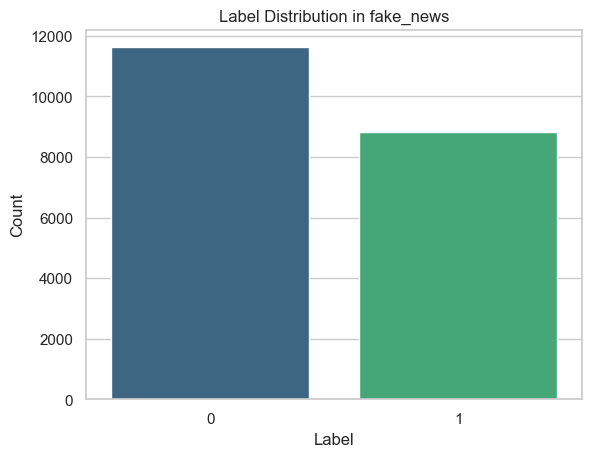


Example token ids and attention masks:
Sample 1:
input_ids: [    1  1430   293 11513  9084   642   286  6326   266 22776 23983   293
  1711   267  2901   263   394   262  7495   295]
attention_mask: [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
label: 1
----------------------------------------
Sample 2:
input_ids: [   1 1083 3220 1002  280  268  692 1753 5387 2556  264 7970 1627 1747
  265  353 3049 3013  641  262]
attention_mask: [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
label: 0
----------------------------------------
Sample 3:
input_ids: [    1   279  1282  2329   265   262  1813  4241   287   476 37586   285
   357   277  1623   278   284   570   266  1001]
attention_mask: [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
label: 0
----------------------------------------

=== Domain: political_statements ===
Number of samples: 12497
Average tokenized length: 512.0
Label distribution:
{1: 8042, 0: 4455}


C:\Users\ASUS\AppData\Local\Temp\ipykernel_18764\3923799651.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette="viridis", dodge=False)


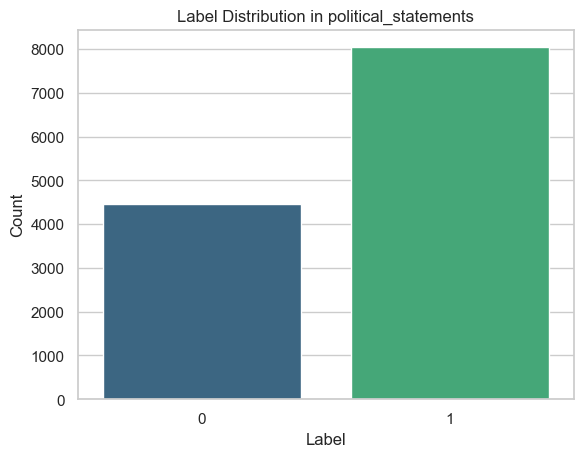

C:\Users\ASUS\AppData\Local\Temp\ipykernel_18764\3923799651.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette="viridis", dodge=False)



Example token ids and attention masks:
Sample 1:
input_ids: [    1 13858   261   262  8070   265  2036  2303   269   591 10037  2947
   385 10037  2947   270  1505   727   441   262]
attention_mask: [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
label: 1
----------------------------------------
Sample 2:
input_ids: [    1   273  6168   270   388   272   301   389   264   825   292   266
   382 53520 10545 56488  1132   280   264   266]
attention_mask: [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
label: 1
----------------------------------------
Sample 3:
input_ids: [   1  279  750  702  280  297  553  262 7206 1355  265  262 8559  272
  284  446  277  288  733 5406]
attention_mask: [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
label: 0
----------------------------------------

=== Domain: product_reviews ===
Number of samples: 20971
Average tokenized length: 512.0
Label distribution:
{1: 10492, 0: 10479}


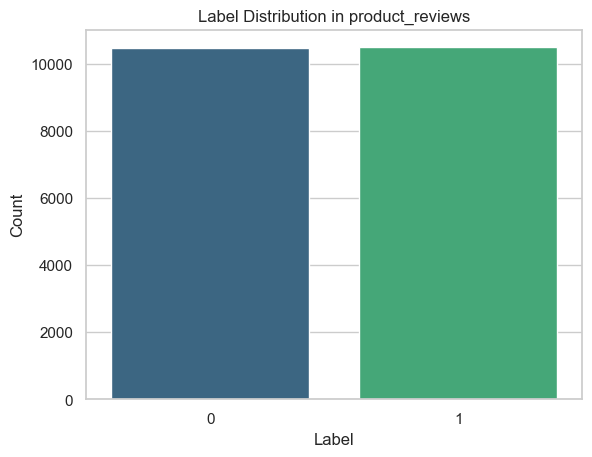

C:\Users\ASUS\AppData\Local\Temp\ipykernel_18764\3923799651.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette="viridis", dodge=False)



Example token ids and attention masks:
Sample 1:
input_ids: [    1   851   260   802 98174   284 16711   260   260   260   951   267
   315 78456   268   261   304   267   291   571]
attention_mask: [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
label: 1
----------------------------------------
Sample 2:
input_ids: [    1  2099   312  1180   261   291   269   311   265   262   410  8937
  2859   274   295   433   270 18116  4922  8937]
attention_mask: [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
label: 1
----------------------------------------
Sample 3:
input_ids: [    1   463   340 18640   286  1979   261   262  5064   270   291   714
  5325  6139   262 16462   296  3753  4514   260]
attention_mask: [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
label: 0
----------------------------------------

=== Domain: job_scams ===
Number of samples: 14295
Average tokenized length: 512.0
Label distribution:
{0: 13696, 1: 599}


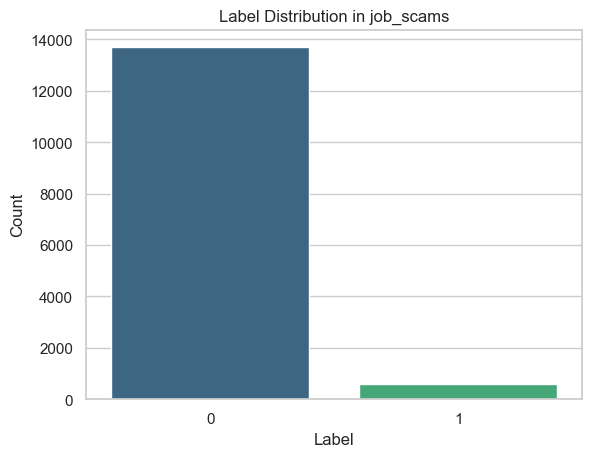


Example token ids and attention masks:
Sample 1:
input_ids: [    1   279 15784   502   917   263  1455   316  2947  2363  1380  2808
   967  1567   261   636   277   831   683  2737]
attention_mask: [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
label: 0
----------------------------------------
Sample 2:
input_ids: [    1   345   281   562   270   266  1835   263 18592   267   305  2592
   265   645  3822   261   560  2666  7653   260]
attention_mask: [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
label: 0
----------------------------------------
Sample 3:
input_ids: [    1 19621  5435 18910  8171  2200  2493  4012 19621  5435   280   268
   485   920   832   269  1479   261   263   301]
attention_mask: [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
label: 0
----------------------------------------

=== Domain: sms ===
Number of samples: 6574
Average tokenized length: 512.0
Label distribution:
{0: 5300, 1: 1274}


C:\Users\ASUS\AppData\Local\Temp\ipykernel_18764\3923799651.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette="viridis", dodge=False)


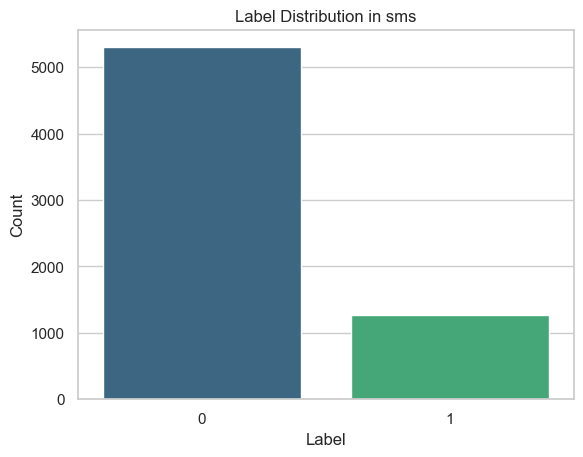


Example token ids and attention masks:
Sample 1:
input_ids: [    1   345   412   278   300 77792   288 65562   935   269   621   703
   283  2784   261   875   272  1550   449  5522]
attention_mask: [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
label: 0
----------------------------------------
Sample 2:
input_ids: [    1 11834 16960  2368 28849   452 59315   667 26178 12345   280     2
     0     0     0     0     0     0     0     0]
attention_mask: [1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0]
label: 0
----------------------------------------
Sample 3:
input_ids: [    1   585   389   264   504   784   264   351   260   273   391   584
   481   299 25390     2     0     0     0     0]
attention_mask: [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0]
label: 0
----------------------------------------

=== Domain: twitter_rumours ===
Number of samples: 5789
Average tokenized length: 512.0
Label distribution:
{0: 3820, 1: 1969}


C:\Users\ASUS\AppData\Local\Temp\ipykernel_18764\3923799651.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette="viridis", dodge=False)


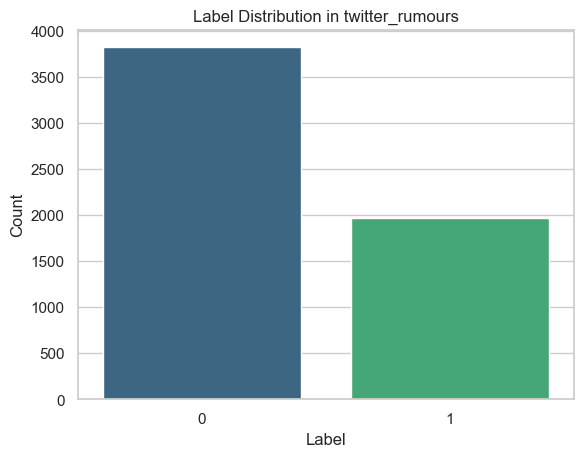


Example token ids and attention masks:
Sample 1:
input_ids: [  1 273 418 280 297 391 361 291 269 446 264 513 260 420 642 261 278 702
 280 297]
attention_mask: [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
label: 0
----------------------------------------
Sample 2:
input_ids: [    1 28223  3853  3764 23517   355 12544   267   262  1796 23171  2368
  2788   292  4136   264  2439   260  2324 45739]
attention_mask: [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
label: 1
----------------------------------------
Sample 3:
input_ids: [    1  9187   265   262  1972 23388   385  1337 20389   267  9720   291
  1066   260  2569 11698  1504  2569 11698  1504]
attention_mask: [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
label: 0
----------------------------------------


In [26]:
summarize_domains(processed_domains)


In [27]:
import os

save_dir = "../data/prepared_domains"
os.makedirs(save_dir, exist_ok=True)

for domain, df in processed_domains.items():
    # Save as pickle
    pkl_path = os.path.join(save_dir, f"{domain}_processed.pkl")
    df.to_pickle(pkl_path)
    
    # Save as CSV
    csv_path = os.path.join(save_dir, f"{domain}_processed.csv")
    df.to_csv(csv_path, index=False)
    
    print(f"✅ Saved {domain} processed set as pickle ({pkl_path}) and CSV ({csv_path})")


✅ Saved phishing processed set as pickle (../data/prepared_domains\phishing_processed.pkl) and CSV (../data/prepared_domains\phishing_processed.csv)
✅ Saved fake_news processed set as pickle (../data/prepared_domains\fake_news_processed.pkl) and CSV (../data/prepared_domains\fake_news_processed.csv)
✅ Saved political_statements processed set as pickle (../data/prepared_domains\political_statements_processed.pkl) and CSV (../data/prepared_domains\political_statements_processed.csv)
✅ Saved product_reviews processed set as pickle (../data/prepared_domains\product_reviews_processed.pkl) and CSV (../data/prepared_domains\product_reviews_processed.csv)
✅ Saved job_scams processed set as pickle (../data/prepared_domains\job_scams_processed.pkl) and CSV (../data/prepared_domains\job_scams_processed.csv)
✅ Saved sms processed set as pickle (../data/prepared_domains\sms_processed.pkl) and CSV (../data/prepared_domains\sms_processed.csv)
✅ Saved twitter_rumours processed set as pickle (../data/p